Total entries = 100000

========== Diagnostics ==========
Events used = 102
Compton scatter points found = 106
Detector gamma hits found = 102
Cones used = 62
Max image value = 5.7804311974273395



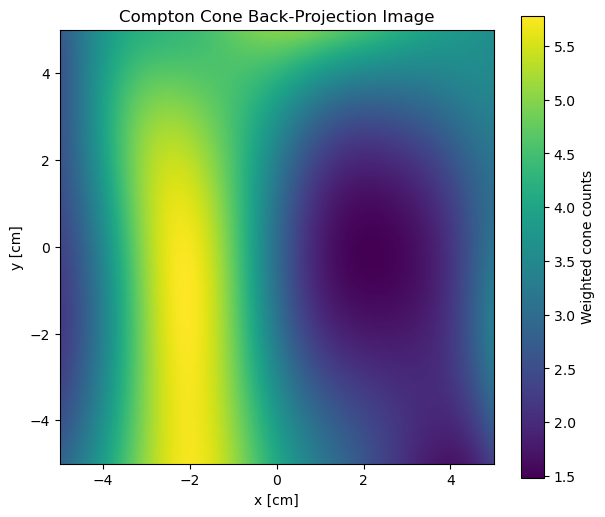

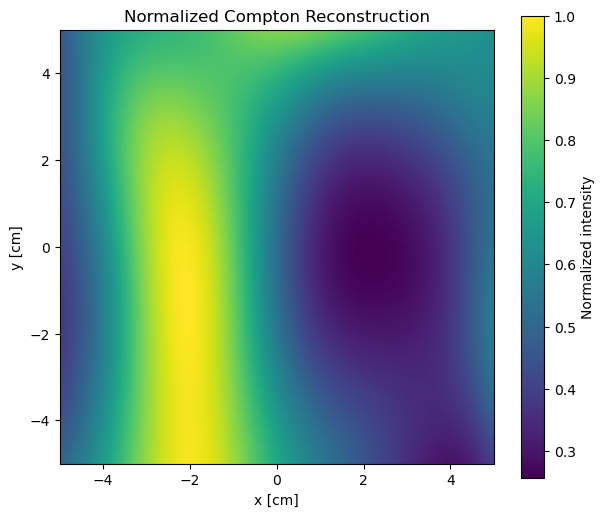

In [4]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

# Optional smoothing
try:
    from scipy.ndimage import gaussian_filter
    use_scipy = True
except ImportError:
    use_scipy = False

# =========================
# USER SETTINGS
# =========================
root_file = "tumor.root"
tree_name = "t"

E0 = 662.0     # incident gamma energy [keV]
me = 511.0     # electron rest energy [keV]

phantom_vlms = [2, 3]       # phantom + tumor
detector_vlms = [4, 5, 6]   # detectors

# Try 2013 first. If empty, try 2012 or None.
compton_process_code = 2013
# compton_process_code = None

xmin, xmax = -5.0, 5.0
ymin, ymax = -5.0, 5.0
z_slice = 0.0

nx, ny = 150, 150

# Gaussian angular uncertainty, radians
sigma_theta = 0.05

# Limit events for testing. Use None for all events.
max_events = None
# max_events = 5000

# Smooth final image
apply_smoothing = True
smooth_sigma = 1.5

# =========================
# OPEN ROOT FILE
# =========================
f = ROOT.TFile.Open(root_file)
if not f or f.IsZombie():
    raise RuntimeError("Could not open ROOT file")

t = f.Get(tree_name)
if not t:
    raise RuntimeError("Could not find tree named " + tree_name)

print("Total entries =", t.GetEntries())

# =========================
# IMAGE GRID
# =========================
xgrid = np.linspace(xmin, xmax, nx)
ygrid = np.linspace(ymin, ymax, ny)

image = np.zeros((ny, nx))

# Precompute grid points
XX, YY = np.meshgrid(xgrid, ygrid)
ZZ = np.full_like(XX, z_slice)

# Diagnostics
n_events_used = 0
n_scatter_total = 0
n_detector_total = 0
n_cones_used = 0

# Required branches
branches = ["pdg", "vlm", "pro", "trk", "stp", "de", "et", "x", "y", "z"]

# =========================
# LOOP OVER ROOT TREE
# =========================
for iev, entry in enumerate(t):

    if max_events is not None and iev >= max_events:
        break

    # Safe length
    try:
        n = min(len(getattr(entry, b)) for b in branches)
    except Exception:
        continue

    if n == 0:
        continue

    scatter_points = []
    detector_hits = []

    # =========================
    # COLLECT POINTS IN ONE EVENT
    # =========================
    for i in range(n):

        pdg = int(entry.pdg[i])
        vlm = int(entry.vlm[i])
        pro = int(entry.pro[i])
        trk = int(entry.trk[i])
        stp = int(entry.stp[i])

        x = float(entry.x[i])
        y = float(entry.y[i])
        z = float(entry.z[i])

        de = float(entry.de[i])
        et = float(entry.et[i])

        # -------------------------
        # Compton scatter point
        # -------------------------
        is_compton = True
        if compton_process_code is not None:
            is_compton = (pro == compton_process_code)

        if (
            pdg == 22 and
            vlm in phantom_vlms and
            is_compton
        ):
            scatter_points.append({
                "x": x,
                "y": y,
                "z": z,
                "trk": trk,
                "stp": stp,
                "de": de,
                "et": et
            })

        # -------------------------
        # Gamma detector hit
        # -------------------------
        if (
            pdg == 22 and
            vlm in detector_vlms and
            et > 0
        ):
            detector_hits.append({
                "x": x,
                "y": y,
                "z": z,
                "trk": trk,
                "stp": stp,
                "de": de,
                "et": et
            })

    if len(scatter_points) == 0 or len(detector_hits) == 0:
        continue

    n_scatter_total += len(scatter_points)
    n_detector_total += len(detector_hits)
    n_events_used += 1

    # =========================
    # USE FIRST COMPTON POINT PER TRACK
    # =========================
    first_scatter_by_track = {}

    for sp in scatter_points:
        trk = sp["trk"]

        if trk not in first_scatter_by_track:
            first_scatter_by_track[trk] = sp
        else:
            if sp["stp"] < first_scatter_by_track[trk]["stp"]:
                first_scatter_by_track[trk] = sp

    # =========================
    # BACKPROJECT CONES
    # =========================
    for trk, sp in first_scatter_by_track.items():

        sx = sp["x"]
        sy = sp["y"]
        sz = sp["z"]

        # Find detector hits from same track
        same_track_hits = [dh for dh in detector_hits if dh["trk"] == trk]

        if len(same_track_hits) == 0:
            continue

        # Use first detector hit for this track
        dh = same_track_hits[0]

        dx = dh["x"]
        dy = dh["y"]
        dz = dh["z"]
        Eprime = dh["et"]

        if Eprime <= 0:
            continue

        # =========================
        # COMPTON ANGLE
        # =========================
        cos_theta = 1.0 - me * (1.0 / Eprime - 1.0 / E0)

        if cos_theta < -1.0 or cos_theta > 1.0:
            continue

        theta = np.arccos(cos_theta)

        # Cone axis: scatter point to detector hit
        axis = np.array([dx - sx, dy - sy, dz - sz])
        axis_norm = np.linalg.norm(axis)

        if axis_norm == 0:
            continue

        axis = axis / axis_norm

        # Vectors from scatter point to every image pixel
        VX = XX - sx
        VY = YY - sy
        VZ = ZZ - sz

        R = np.sqrt(VX**2 + VY**2 + VZ**2)

        # Avoid division by zero
        mask = R > 0

        dot = np.zeros_like(R)
        dot[mask] = (
            VX[mask] * axis[0] +
            VY[mask] * axis[1] +
            VZ[mask] * axis[2]
        ) / R[mask]

        dot = np.clip(dot, -1.0, 1.0)

        pixel_angle = np.arccos(dot)

        delta = pixel_angle - theta

        # Gaussian weighting instead of hard cutoff
        weight = np.exp(-0.5 * (delta / sigma_theta)**2)

        image += weight

        n_cones_used += 1

    if iev % 1000 == 0:
        print("Processed event", iev)

# =========================
# POST-PROCESS IMAGE
# =========================
if apply_smoothing and use_scipy:
    image = gaussian_filter(image, sigma=smooth_sigma)

if np.max(image) > 0:
    image_norm = image / np.max(image)
else:
    image_norm = image

# =========================
# PRINT DIAGNOSTICS
# =========================
print("\n========== Diagnostics ==========")
print("Events used =", n_events_used)
print("Compton scatter points found =", n_scatter_total)
print("Detector gamma hits found =", n_detector_total)
print("Cones used =", n_cones_used)
print("Max image value =", np.max(image))
print("=================================\n")

# =========================
# PLOT RAW IMAGE
# =========================
plt.figure(figsize=(7, 6))
plt.imshow(
    image,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal"
)
plt.colorbar(label="Weighted cone counts")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Compton Cone Back-Projection Image")
plt.show()

# =========================
# PLOT NORMALIZED IMAGE
# =========================
plt.figure(figsize=(7, 6))
plt.imshow(
    image_norm,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="equal"
)
plt.colorbar(label="Normalized intensity")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Normalized Compton Reconstruction")
plt.show()